# Лабораторная работа №5. Построение нейронных сетей для Q-обучения с помощью PyTourch и Tensorflow

### 1.Использование Tensorflow

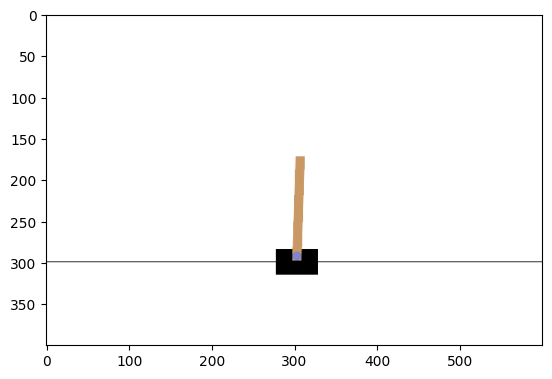

In [4]:
import sys, os

if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = ':1'

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array").env
env.reset()
n_actions = int(env.action_space.n)
state_dim = env.observation_space.shape
plt.imshow(env.render())

In [5]:
import tensorflow as tf
import keras
import keras.layers as L

assert len(tf.config.list_physical_devices('GPU')) == 0, \
    "Пожалуйста, выполните это задание без графического процессора. Если вы используете графический процессор, код " \
    "будет работать намного медленнее из-за большого количества операций копирования в память графического процессора и из нее." 

In [6]:
network = keras.models.Sequential()
# Архитектура модели 
network.add(L.InputLayer(state_dim)) # Входной слой 
network.add(L.Dense(64, activation='relu')) # первый скрытый слой
network.add(L.Dense(64, activation='relu')) # второй скрытый слой
network.add(L.Dense(n_actions, activation='linear')) # выходной слой 
network.compile(optimizer='adam', loss='mse')

def get_action(state, epsilon=0):
    """эпсилон-жадная политика (чистый TF2, без predict)"""
    
    state_tensor = tf.convert_to_tensor(state[None, ...], dtype=tf.float32)
    
    q_values = network(state_tensor, training=False).numpy()[0]
    
    if np.random.random() < epsilon:
        return np.random.randint(len(q_values))
    else:
        return np.argmax(q_values)
    
# ПРОВЕРКА
assert network.output_shape == (None, n_actions), \
    "пожалуйста, убедитесь, что ваша модельотображает состояние s -> [Q(s,a0),..., Q(s, a_last)]"

assert network.layers[-1].activation == keras.activations.linear, \
    "пожалуйста, убедитесь, что вы предсказываете q-значения без нелинейности"
    
s, _ = env.reset()
assert np.shape(get_action(s)) == (), "верните только одно действие (integer)"

for eps in [0., 0.1, 0.5, 1.0]:
    state_frequencies = np.bincount([get_action(s, epsilon=eps) for _ in range(1000)], minlength=n_actions)
    best_action = state_frequencies.argmax()
    
    assert abs(state_frequencies[best_action] - 1000 * (1 - eps + eps / n_actions)) < 200
    
    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] - 1000 * (eps / n_actions)) < 200
    
    print('e=%.1f tests passed'%eps)


e=0.0 tests passed
e=0.1 tests passed
e=0.5 tests passed
e=1.0 tests passed


**Q-обучение через градиентный спуск**
$$
L = \frac{1}{N} \sum_i (Q_\Theta(s,a) - [r(s, a) + \gamma* \max_{a'} Q(s', a')])^2
$$
где: $\\$
$s$ - текущее состояние
$a$ - действие 
$r$ - вознаграждение 
$s'$ - следующее состояние
$\gamma$ - коэффициент дисконтирования

Сложная часть связана с $Q(s′,a′)$. $\\$
С инженерной точки зрения это то же самое, что и 
$Q_\Theta$ — результат политики вашей нейронной сети. Однако при градиентном спуске мы не будем распространять через него градиенты, чтобы сделать обучение более стабильным. Для этого мы будем использовать функцию tf.stop_gradient, которая говорит: «Считайте эту вещь постоянной при выполнении backprop».

In [7]:
gamma = 0.9
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4) 

def train_step(state, action, reward, next_state, done):
    # Превращаем входные данные в тензоры и добавляем batch dimension
    state = tf.convert_to_tensor(state[None, ...], dtype=tf.float32)
    action = tf.convert_to_tensor([action], dtype=tf.int32)
    reward = tf.convert_to_tensor([reward], dtype=tf.float32)
    next_state = tf.convert_to_tensor(next_state[None, ...], dtype=tf.float32)
    done = tf.convert_to_tensor([done], dtype=tf.bool)

    with tf.GradientTape() as tape:
        # Q-значения для текущего состояния (batch=1)
        q_s = network(state, training=True)                # shape (1, n_actions)
        # Q-значения для следующего состояния (без градиента через target)
        q_next_s = network(next_state, training=False)     # shape (1, n_actions)

        # Значение следующего состояния: max_a Q(s', a)
        next_state_values = tf.reduce_max(q_next_s, axis=1)  # shape (1,)

        # Целевое значение для выбранного действия
        target = reward + gamma * next_state_values
        # Если состояние терминальное, target = reward
        target = tf.where(done, reward, target)            # shape (1,)

        # Берём предсказанное Q для действия action
        # Используем tf.gather с batch_dims=1, чтобы выбрать нужные действия
        q_for_action = tf.gather(q_s, action, batch_dims=1)  # shape (1,)

        # Ошибка: MSE между предсказанием и target (с остановкой градиента для target)
        loss = tf.reduce_mean((q_for_action - tf.stop_gradient(target)) ** 2)

    # Вычисляем градиенты и обновляем веса модели
    grads = tape.gradient(loss, network.trainable_variables)
    optimizer.apply_gradients(zip(grads, network.trainable_variables))
    return loss.numpy()  # возвращаем значение потери для информации


Игры с моделью

In [8]:
def generate_session(env, t_max=1000, epsilon=0, train=False):
    total_reward = 0
    s, _ = env.reset()
    for t in range(t_max):
        a = get_action(s, epsilon=epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        if train:
            loss_val = train_step(s, a, r, next_s, done) 
            
        total_reward += r
        s = next_s
        if done:
            break
    return total_reward

In [12]:
epsilon = 0.5

for i in range(100):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]
    
    print("epoch #{}\tmean reward = {:.3f}\tepsilon = {:.3f}".format(i, np.mean(session_rewards), epsilon))
    epsilon *= 0.99
    
    assert epsilon >= 1e-4, " Убедитесь, что эпсилон всегда отличен от нуля во время обучения "
    
    if np.mean(session_rewards) > 150:
        print("You Win!")
        break

epoch #0	mean reward = 118.470	epsilon = 0.500
epoch #1	mean reward = 157.740	epsilon = 0.495
You Win!


### 2.Использование Pytorch

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

state_dim = env.observation_space.shape[0]
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(int(state_dim), 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions)  
        )

    def forward(self, x):
        return self.net(x)

# Инициализация модели и оптимизатора
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = QNetwork(state_dim, n_actions).to(device)
optimizer = optim.Adam(network.parameters(), lr=1e-4)
gamma = 0.9


def get_action(state, epsilon=0):
    """Эпсилон-жадная политика"""
    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)  
    
    with torch.no_grad():
        q_values = network(state_tensor).cpu().numpy()[0]
        
    if np.random.random() < epsilon:
        return np.random.randint(len(q_values))
    else:
        return np.argmax(q_values)

# ПРОВЕРКИ 
assert network.net[-1].out_features == n_actions, \
    "Модель должна выдавать Q для каждого действия"
assert isinstance(network.net[-1], nn.Linear), \
    "Последний слой должен быть линейным (без нелинейности)"
    
s, _ = env.reset()
assert np.shape(get_action(s)) == (), "верните только одно действие (integer)"

for eps in [0., 0.1, 0.5, 1.0]:
    actions = [get_action(s, epsilon=eps) for _ in range(1000)]
    state_frequencies = np.bincount(actions, minlength=n_actions)
    best_action = state_frequencies.argmax()
    assert abs(state_frequencies[best_action] - 1000 * (1 - eps + eps / n_actions)) < 200
    for other_action in range(n_actions):
        if other_action != best_action:
            assert abs(state_frequencies[other_action] - 1000 * (eps / n_actions)) < 200
    print(f'e={eps:.1f} tests passed')

e=0.0 tests passed
e=0.1 tests passed
e=0.5 tests passed
e=1.0 tests passed


In [14]:
def train_step(state, action, reward, next_state, done):
    # Преобразование в тензоры и добавление batch-измерения
    state = torch.FloatTensor(state).unsqueeze(0).to(device)       
    action = torch.LongTensor([action]).to(device)                
    reward = torch.FloatTensor([reward]).to(device)               
    next_state = torch.FloatTensor(next_state).unsqueeze(0).to(device)  
    done = torch.BoolTensor([done]).to(device)                    
    
    # Вычисление Q-значений
    q_s = network(state)                   
    with torch.no_grad():
        q_next_s = network(next_state)      

    # Значение следующего состояния: max Q(s')
    next_state_values = q_next_s.max(dim=1)[0]
    # Целевое значение
    target = reward + gamma * next_state_values
    target = torch.where(done, reward, target)  # если done, target = reward

    # Q для выбранного действия
    q_for_action = q_s.gather(1, action.unsqueeze(1)).squeeze(1)  # (1,)

    # Вычисление loss (MSE)
    loss = nn.MSELoss()(q_for_action, target.detach())

    # Шаг оптимизации
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

# Генерация одной сессии 
def generate_session(env, t_max=1000, epsilon=0, train=False):
    total_reward = 0
    s, _ = env.reset()
    for t in range(t_max):
        a = get_action(s, epsilon=epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated

        if train:
            loss_val = train_step(s, a, r, next_s, done)

        total_reward += r
        s = next_s
        if done:
            break
    return total_reward

In [15]:
epsilon = 0.5

for i in range(100):
    session_rewards = [generate_session(env, epsilon=epsilon, train=True) for _ in range(100)]

    print(f"epoch #{i}\tmean reward = {np.mean(session_rewards):.3f}\tepsilon = {epsilon:.3f}")
    epsilon *= 0.99

    assert epsilon >= 1e-4, "Убедитесь, что эпсилон всегда отличен от нуля во время обучения"

    if np.mean(session_rewards) > 150:
        print("You Win!")
        break

epoch #0	mean reward = 13.980	epsilon = 0.500
epoch #1	mean reward = 13.270	epsilon = 0.495
epoch #2	mean reward = 15.020	epsilon = 0.490
epoch #3	mean reward = 20.900	epsilon = 0.485
epoch #4	mean reward = 27.640	epsilon = 0.480
epoch #5	mean reward = 35.260	epsilon = 0.475
epoch #6	mean reward = 39.240	epsilon = 0.471
epoch #7	mean reward = 53.020	epsilon = 0.466
epoch #8	mean reward = 60.850	epsilon = 0.461
epoch #9	mean reward = 75.530	epsilon = 0.457
epoch #10	mean reward = 176.600	epsilon = 0.452
You Win!
